# Day 9/60 — Message Queue

## System Design Series

**Topic:** To further scale a system, we decouple components so they can scale independently. A **Message Queue** is a durable, in-memory buffer that enables asynchronous communication between producers and consumers.

**What we cover:**
- Core MQ architecture: producers → queue → consumers, and async vs sync comparison
- Photo processing use case: web servers publish jobs, workers process independently
- Producer/consumer independence: what happens when each goes offline
- Autoscaling workers based on queue depth
- MQ patterns: Fan-Out/Pub-Sub, Priority Queue, Dead-Letter Queue
- Technology comparison: RabbitMQ vs Kafka vs SQS vs Redis Streams
- Architecture evolution and Day 9 scorecard

---

## 1. Setup: Libraries & Colour Palette

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120})

C_BLUE     = '#4C72B0'
C_GREEN    = '#27AE60'
C_ORANGE   = '#DD8452'
C_RED      = '#C44E52'
C_TEAL     = '#2E86AB'
C_GRAY     = '#F8F9FA'
C_PRODUCER = '#2980B9'   # blue   — producer / publisher
C_QUEUE    = '#E67E22'   # amber  — message queue
C_CONSUMER = '#8E44AD'   # purple — consumer / subscriber
C_MSG      = '#F39C12'   # gold   — individual message
C_ASYNC    = '#27AE60'   # green  — async / decoupled path
C_SYNC     = '#C44E52'   # red    — synchronous / blocking path

print("Libraries loaded. Day 9 ready.")


Libraries loaded. Day 9 ready.


### What this does

Loads Matplotlib and NumPy with the Day 9 colour palette:

| Constant | Colour | Meaning |
|---|---|---|
| `C_PRODUCER` | Blue | Producer / Publisher |
| `C_QUEUE` | Amber | Message Queue |
| `C_CONSUMER` | Purple | Consumer / Subscriber |
| `C_MSG` | Gold | Individual message in queue |
| `C_ASYNC` | Green | Async / decoupled path (the benefit) |
| `C_SYNC` | Red | Synchronous / blocking path (the problem) |

Blue → Amber → Purple traces the message path through the system.

## 2. Core Message Queue Architecture

> "Message Queue is a durable component, stored in memory, that supports asynchronous communication. It serves as a buffer and distributes asynchronous requests." — Day 9

**Three roles:**
- **Producers** (publishers): services that create messages and publish them to the queue
- **Queue**: durable buffer — holds messages until consumers are ready, even if consumers are offline
- **Consumers** (subscribers): services that pull messages from the queue and act on them

The fundamental difference from synchronous calls: the producer does not wait for the consumer to finish. It publishes and immediately returns to its own work.

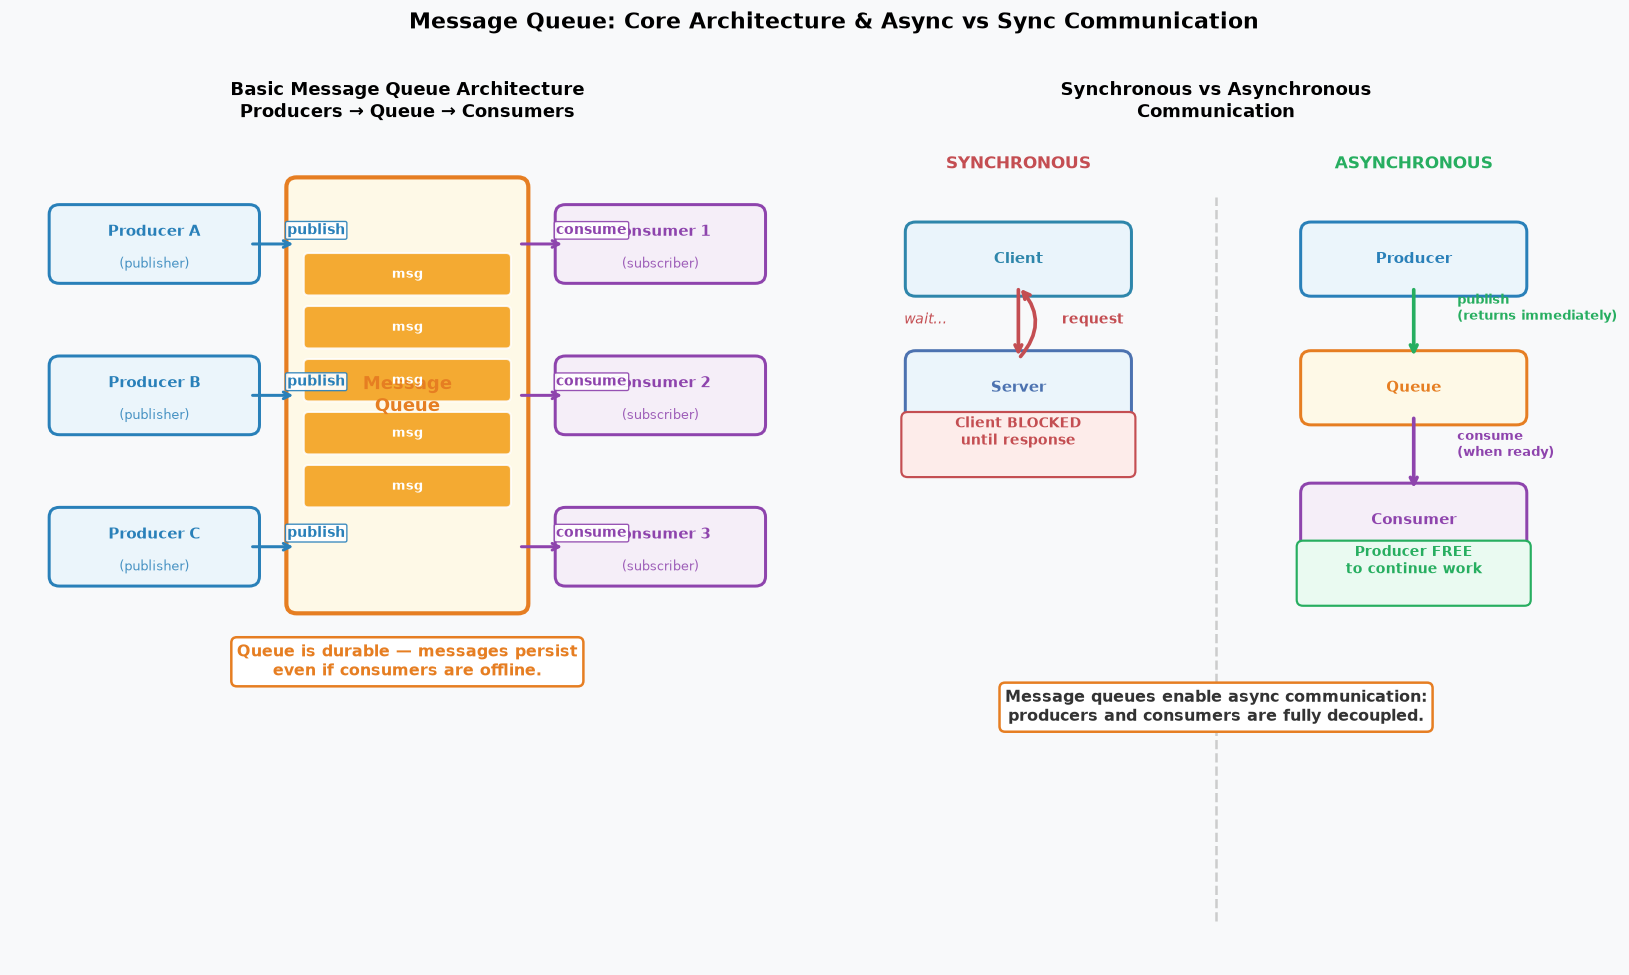

Architecture diagram done.


In [2]:
# Core message queue architecture: Producer → Queue → Consumer
# Clean vertical-column layout, no crossing lines

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.patch.set_facecolor(C_GRAY)

# ── Left: basic MQ flow ───────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 11)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Basic Message Queue Architecture\nProducers → Queue → Consumers',
             fontsize=11, fontweight='bold', pad=8)

def box(ax, x, y, w, h, label, color, bg='white', sub='', fs=9.5, lw=1.8):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.13',
                       facecolor=bg, edgecolor=color, lw=lw)
    ax.add_patch(r)
    ax.text(x, y + (0.16 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.26, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.85)

def arr(ax, x1, y1, x2, y2, label, color, lw=2.0):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        mx, my = (x1 + x2)/2 + 0.18, (y1 + y2)/2 + 0.18
        ax.text(mx, my, label, ha='left', va='center',
                fontsize=8.5, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                          edgecolor=color, lw=0.8, alpha=0.92))

# Producers (left column)
for y, lbl in [(9.5, 'Producer A'), (7.5, 'Producer B'), (5.5, 'Producer C')]:
    box(ax, 1.8, y, 2.4, 0.78, lbl, C_PRODUCER,
        bg='#EBF5FB', sub='(publisher)', fs=9)

# Queue (centre)
box(ax, 5.0, 7.5, 2.8, 5.5, 'Message\nQueue', C_QUEUE,
    bg='#FEF9E7', fs=11, lw=2.5)
# Message slots inside queue
for my, txt in [(9.1, 'msg'), (8.4, 'msg'), (7.7, 'msg'),
                (7.0, 'msg'), (6.3, 'msg')]:
    r = FancyBboxPatch((3.75, my - 0.22), 2.5, 0.44,
                       boxstyle='round,pad=0.06',
                       facecolor=C_MSG, edgecolor='white', lw=1.2, alpha=0.85)
    ax.add_patch(r)
    ax.text(5.0, my, txt, ha='center', va='center',
            fontsize=8, fontweight='bold', color='white')

# Consumers (right column)
for y, lbl in [(9.5, 'Consumer 1'), (7.5, 'Consumer 2'), (5.5, 'Consumer 3')]:
    box(ax, 8.2, y, 2.4, 0.78, lbl, C_CONSUMER,
        bg='#F5EEF8', sub='(subscriber)', fs=9)

# Producer → Queue arrows
for py in [9.5, 7.5, 5.5]:
    arr(ax, 3.0, py, 3.6, py, 'publish', C_PRODUCER, lw=1.8)

# Queue → Consumer arrows
for cy in [9.5, 7.5, 5.5]:
    arr(ax, 6.4, cy, 7.0, cy, 'consume', C_CONSUMER, lw=1.8)

ax.text(5.0, 3.8,
        'Queue is durable — messages persist\n'
        'even if consumers are offline.',
        ha='center', fontsize=9.5, color=C_QUEUE, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor=C_QUEUE, lw=1.5))

# ── Right: sync vs async comparison ──────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 11)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Synchronous vs Asynchronous\nCommunication', fontsize=11, fontweight='bold', pad=8)

# Sync panel
ax.text(2.5, 10.5, 'SYNCHRONOUS', ha='center', fontsize=10,
        fontweight='bold', color=C_SYNC)
box(ax, 2.5, 9.3, 2.6, 0.72, 'Client', C_TEAL, bg='#EAF4FB', fs=9)
box(ax, 2.5, 7.6, 2.6, 0.72, 'Server', C_BLUE, bg='#EBF5FB', fs=9)

ax.annotate('', xy=(2.5, 7.98), xytext=(2.5, 8.94),
            arrowprops=dict(arrowstyle='->', color=C_SYNC, lw=2.2))
ax.text(3.05, 8.45, 'request', ha='left', fontsize=8.5,
        color=C_SYNC, fontweight='bold')
ax.annotate('', xy=(2.5, 8.94), xytext=(2.5, 7.98),
            arrowprops=dict(arrowstyle='->', color=C_SYNC, lw=2.2,
                            connectionstyle='arc3,rad=0.45'))
ax.text(1.6, 8.45, 'wait…', ha='right', fontsize=8.5,
        color=C_SYNC, fontstyle='italic')

ax.add_patch(FancyBboxPatch((1.1, 6.5), 2.8, 0.7,
             boxstyle='round,pad=0.08',
             facecolor='#FDECEA', edgecolor=C_SYNC, lw=1.3))
ax.text(2.5, 6.85,
        'Client BLOCKED\nuntil response',
        ha='center', fontsize=8.5, color=C_SYNC, fontweight='bold')

# Async panel
ax.text(7.5, 10.5, 'ASYNCHRONOUS', ha='center', fontsize=10,
        fontweight='bold', color=C_ASYNC)
box(ax, 7.5, 9.3,  2.6, 0.72, 'Producer', C_PRODUCER, bg='#EBF5FB', fs=9)
box(ax, 7.5, 7.6,  2.6, 0.72, 'Queue',    C_QUEUE,    bg='#FEF9E7', fs=9)
box(ax, 7.5, 5.85, 2.6, 0.72, 'Consumer', C_CONSUMER, bg='#F5EEF8', fs=9)

ax.annotate('', xy=(7.5, 7.98), xytext=(7.5, 8.94),
            arrowprops=dict(arrowstyle='->', color=C_ASYNC, lw=2.2))
ax.text(8.05, 8.5, 'publish\n(returns immediately)', ha='left', fontsize=8,
        color=C_ASYNC, fontweight='bold')
ax.annotate('', xy=(7.5, 6.23), xytext=(7.5, 7.24),
            arrowprops=dict(arrowstyle='->', color=C_CONSUMER, lw=2.2))
ax.text(8.05, 6.7, 'consume\n(when ready)', ha='left', fontsize=8,
        color=C_CONSUMER, fontweight='bold')

ax.add_patch(FancyBboxPatch((6.1, 4.8), 2.8, 0.7,
             boxstyle='round,pad=0.08',
             facecolor='#EAFAF1', edgecolor=C_ASYNC, lw=1.3))
ax.text(7.5, 5.15,
        'Producer FREE\nto continue work',
        ha='center', fontsize=8.5, color=C_ASYNC, fontweight='bold')

ax.axvline(5.0, ymin=0.05, ymax=0.92, color='#CCC', lw=1.5, linestyle='--')

ax.text(5.0, 3.2,
        'Message queues enable async communication:\n'
        'producers and consumers are fully decoupled.',
        ha='center', fontsize=9.5, color='#333', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor=C_QUEUE, lw=1.5))

plt.suptitle('Message Queue: Core Architecture & Async vs Sync Communication',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day9_architecture.png', dpi=130, bbox_inches='tight')
plt.show()
print("Architecture diagram done.")


### What these diagrams show

**Left — Basic MQ Architecture:**  
Three producers (blue) on the left publish to a central queue (amber, with 5 message slots). Three consumers (purple) on the right pull from the queue independently. Each producer-to-queue and queue-to-consumer arrow is independent — there is no direct producer-to-consumer link.

**Right — Synchronous vs Asynchronous:**  
The left column (red) shows synchronous communication: the client sends a request and is **blocked** until the server responds. The right column (green) shows the async path: the producer publishes and **immediately returns** — it does not wait for the consumer to process the message. The dashed divider separates the two patterns.

## 3. Photo Processing Use Case

> "Application supports photo customization, including cropping, sharpening, blurring, etc. These customizations take time to complete. Web servers publish photo processing jobs to the message queue and asynchronously perform photo customization tasks." — Day 9

This is the canonical example for message queues:

- A user uploads a photo and requests processing (crop, blur, sharpen)
- The **web server** immediately returns HTTP 200 — the user is not blocked
- A **crop job**, **blur job**, or **sharpen job** message is pushed to the queue
- A pool of **worker processes** pulls jobs from the queue and performs the actual processing
- The result is stored in object storage (S3/GCS/Azure Blob)

**The key insight:** web servers and workers are completely independent. A slow worker does not slow down the web server. A crashed web server does not lose queued jobs.

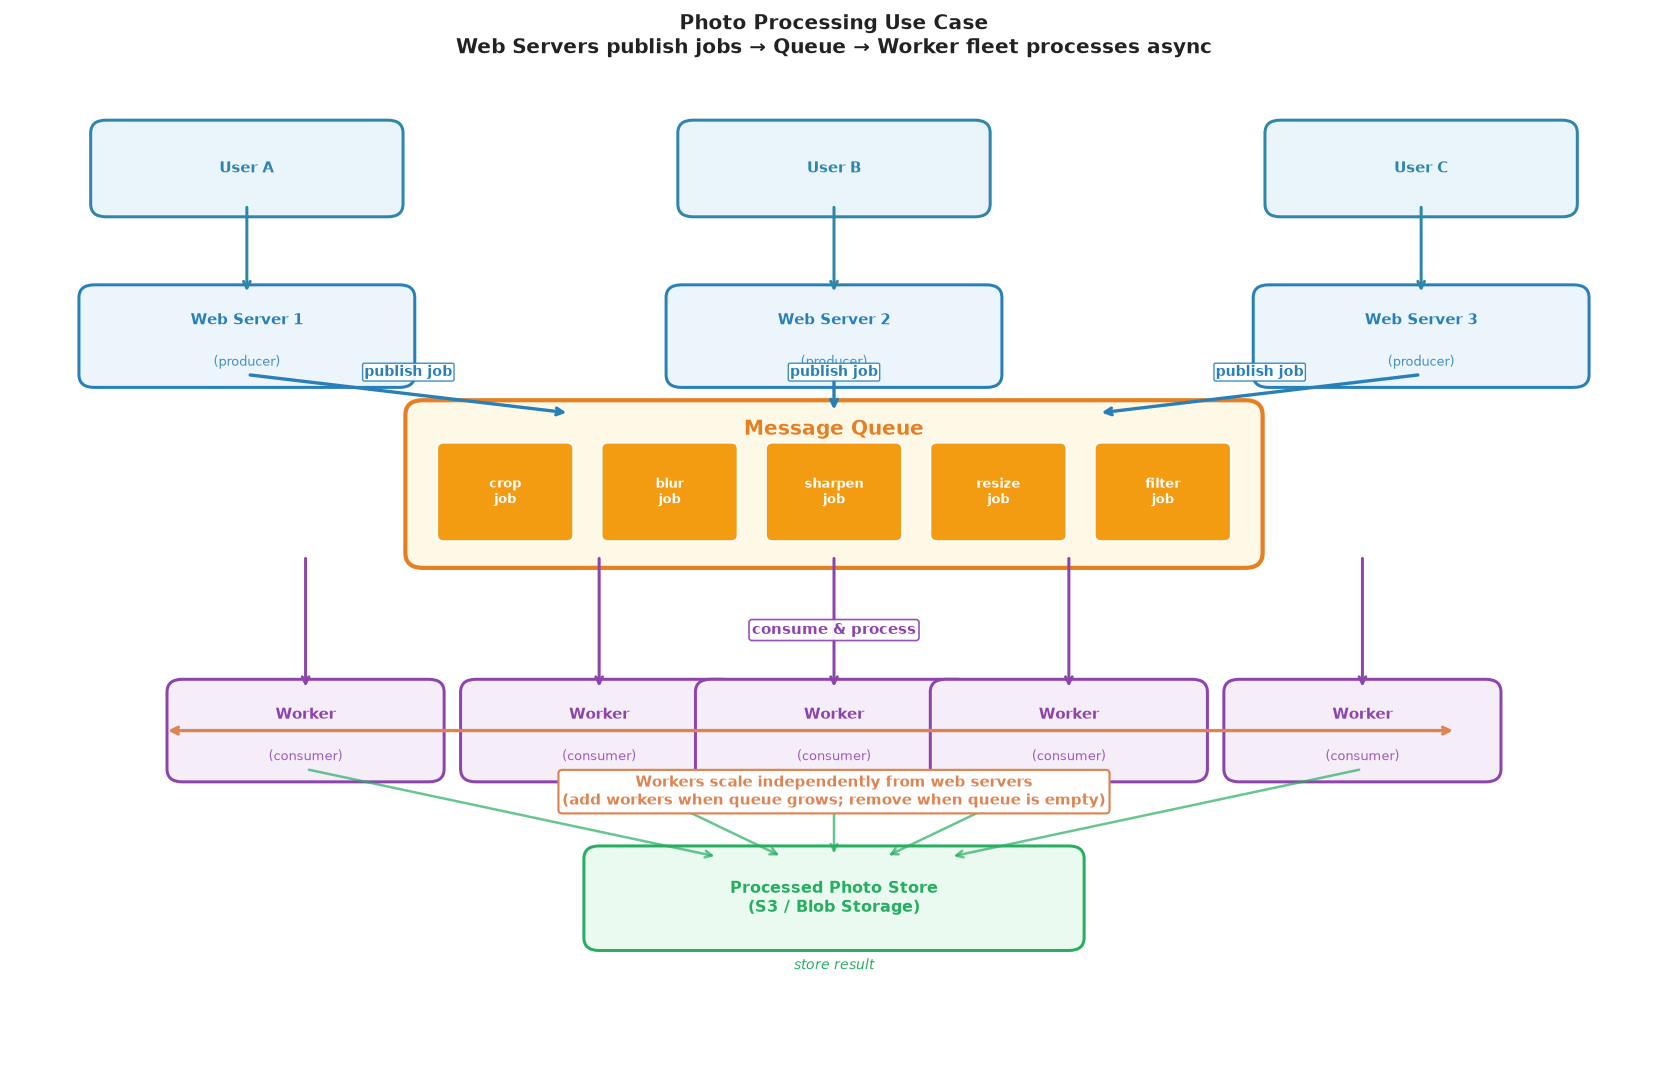

Photo use case diagram done.


In [3]:
# Photo processing use case: Web Server → MQ → Worker fleet
# Exact pattern from Day 9 content: crop/sharpen/blur jobs

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14); ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

def rbox(ax, x, y, w, h, label, color, bg='white', sub='', fs=9.5, lw=1.8):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.13',
                       facecolor=bg, edgecolor=color, lw=lw)
    ax.add_patch(r)
    ax.text(x, y + (0.16 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.26, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.85)

def arr(ax, x1, y1, x2, y2, label, color, lw=2.0):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        mx, my = (x1 + x2)/2, (y1 + y2)/2 + 0.22
        ax.text(mx, my, label, ha='center', va='center',
                fontsize=8.5, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                          edgecolor=color, lw=0.8, alpha=0.92))

# ── Tier 1: Users ─────────────────────────────────────────────────────────────
rbox(ax, 2.0, 9.0, 2.4, 0.72, 'User A', C_TEAL, bg='#EAF4FB', fs=9)
rbox(ax, 7.0, 9.0, 2.4, 0.72, 'User B', C_TEAL, bg='#EAF4FB', fs=9)
rbox(ax, 12.0,9.0, 2.4, 0.72, 'User C', C_TEAL, bg='#EAF4FB', fs=9)

# ── Tier 2: Web Servers (Producers) ──────────────────────────────────────────
rbox(ax, 2.0, 7.3, 2.6, 0.78, 'Web Server 1', C_PRODUCER,
     bg='#EBF5FB', sub='(producer)', fs=9)
rbox(ax, 7.0, 7.3, 2.6, 0.78, 'Web Server 2', C_PRODUCER,
     bg='#EBF5FB', sub='(producer)', fs=9)
rbox(ax, 12.0,7.3, 2.6, 0.78, 'Web Server 3', C_PRODUCER,
     bg='#EBF5FB', sub='(producer)', fs=9)

# User → Web Server
for ux in [2.0, 7.0, 12.0]:
    arr(ax, ux, 8.64, ux, 7.72, '', C_TEAL, lw=1.8)

# ── Tier 3: Message Queue ─────────────────────────────────────────────────────
queue_bg = FancyBboxPatch((3.5, 5.1), 7.0, 1.4,
                           boxstyle='round,pad=0.15',
                           facecolor='#FEF9E7', edgecolor=C_QUEUE, lw=2.5)
ax.add_patch(queue_bg)
ax.text(7.0, 6.3, 'Message Queue', ha='center', fontsize=12,
        fontweight='bold', color=C_QUEUE)

# Message slots in queue
job_labels = ['crop\njob', 'blur\njob', 'sharpen\njob',
              'resize\njob', 'filter\njob']
for j, (jx, jlbl) in enumerate(zip(np.linspace(4.2, 9.8, 5), job_labels)):
    r = FancyBboxPatch((jx - 0.52, 5.28), 1.04, 0.88,
                       boxstyle='round,pad=0.06',
                       facecolor=C_MSG, edgecolor='white', lw=1.2)
    ax.add_patch(r)
    ax.text(jx, 5.72, jlbl, ha='center', va='center',
            fontsize=7.5, fontweight='bold', color='white')

# Web Servers → Queue arrows
for wx in [2.0, 7.0, 12.0]:
    arr(ax, wx, 6.91, wx*0.45 + 7.0*0.55, 6.52,
        'publish job', C_PRODUCER, lw=2.0)

# ── Tier 4: Worker fleet (Consumers) ─────────────────────────────────────────
worker_xs = [2.5, 5.0, 7.0, 9.0, 11.5]
for wx in worker_xs:
    rbox(ax, wx, 3.3, 2.1, 0.78, 'Worker', C_CONSUMER,
         bg='#F5EEF8', sub='(consumer)', fs=9)
    arr(ax, wx, 5.08, wx, 3.71, '', C_CONSUMER, lw=1.8)

# Queue → Workers label
ax.text(7.0, 4.28, 'consume & process', ha='center', fontsize=9,
        color=C_CONSUMER, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor=C_CONSUMER, lw=1.0, alpha=0.92))

# ── Tier 5: Result store ──────────────────────────────────────────────────────
rbox(ax, 7.0, 1.6, 4.0, 0.8, 'Processed Photo Store\n(S3 / Blob Storage)',
     C_GREEN, bg='#EAFAF1', fs=9.5)
for wx in worker_xs:
    ax.annotate('', xy=(7.0 + (wx - 7.0)*0.22, 2.02),
                xytext=(wx, 2.91),
                arrowprops=dict(arrowstyle='->', color=C_GREEN, lw=1.5, alpha=0.7))
ax.text(7.0, 0.88, 'store result', ha='center', fontsize=8.5,
        color=C_GREEN, fontstyle='italic')

# ── Autoscale bracket ─────────────────────────────────────────────────────────
ax.annotate('', xy=(12.3, 3.3), xytext=(1.3, 3.3),
            arrowprops=dict(arrowstyle='<->', color=C_ORANGE, lw=2.0))
ax.text(7.0, 2.55, 'Workers scale independently from web servers\n'
        '(add workers when queue grows; remove when queue is empty)',
        ha='center', fontsize=9, color=C_ORANGE, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor=C_ORANGE, lw=1.3))

ax.set_title('Photo Processing Use Case\nWeb Servers publish jobs → Queue → Worker fleet processes async',
             fontsize=12, fontweight='bold', color='#222', pad=10)
plt.tight_layout()
plt.savefig('/tmp/sd_day9_photo_usecase.png', dpi=130, bbox_inches='tight')
plt.show()
print("Photo use case diagram done.")


### What this shows

Five tiers in a clean top-to-bottom flow:

1. **Users** (teal) → 2. **Web Servers / Producers** (blue): users upload photos; web servers accept the request and return immediately
3. **Message Queue** (amber): holds crop, blur, sharpen, resize, and filter jobs as individual message slots
4. **Worker Fleet / Consumers** (purple): 5 workers pull jobs and process them in parallel; the orange double-headed arrow marks the autoscale boundary — workers are added or removed independently from web servers
5. **Processed Photo Store** (green): workers write results to object storage

The web servers have no arrow to the workers — they are fully decoupled through the queue.

## 4. Producer-Consumer Independence

> "With a message queue, producer can post a message to the queue when the consumer is unavailable to process it. Consumer can read messages from the queue even when the producer is unavailable." — Day 9

This is the **durability guarantee**: the queue acts as a buffer between two independently failing systems. The two failure scenarios are asymmetric:

- **Consumer offline:** messages accumulate in the queue. When the consumer recovers, it processes all buffered messages in order — no data is lost.
- **Producer offline:** messages already in the queue remain available. The consumer drains the existing queue until it is empty — it is never blocked.

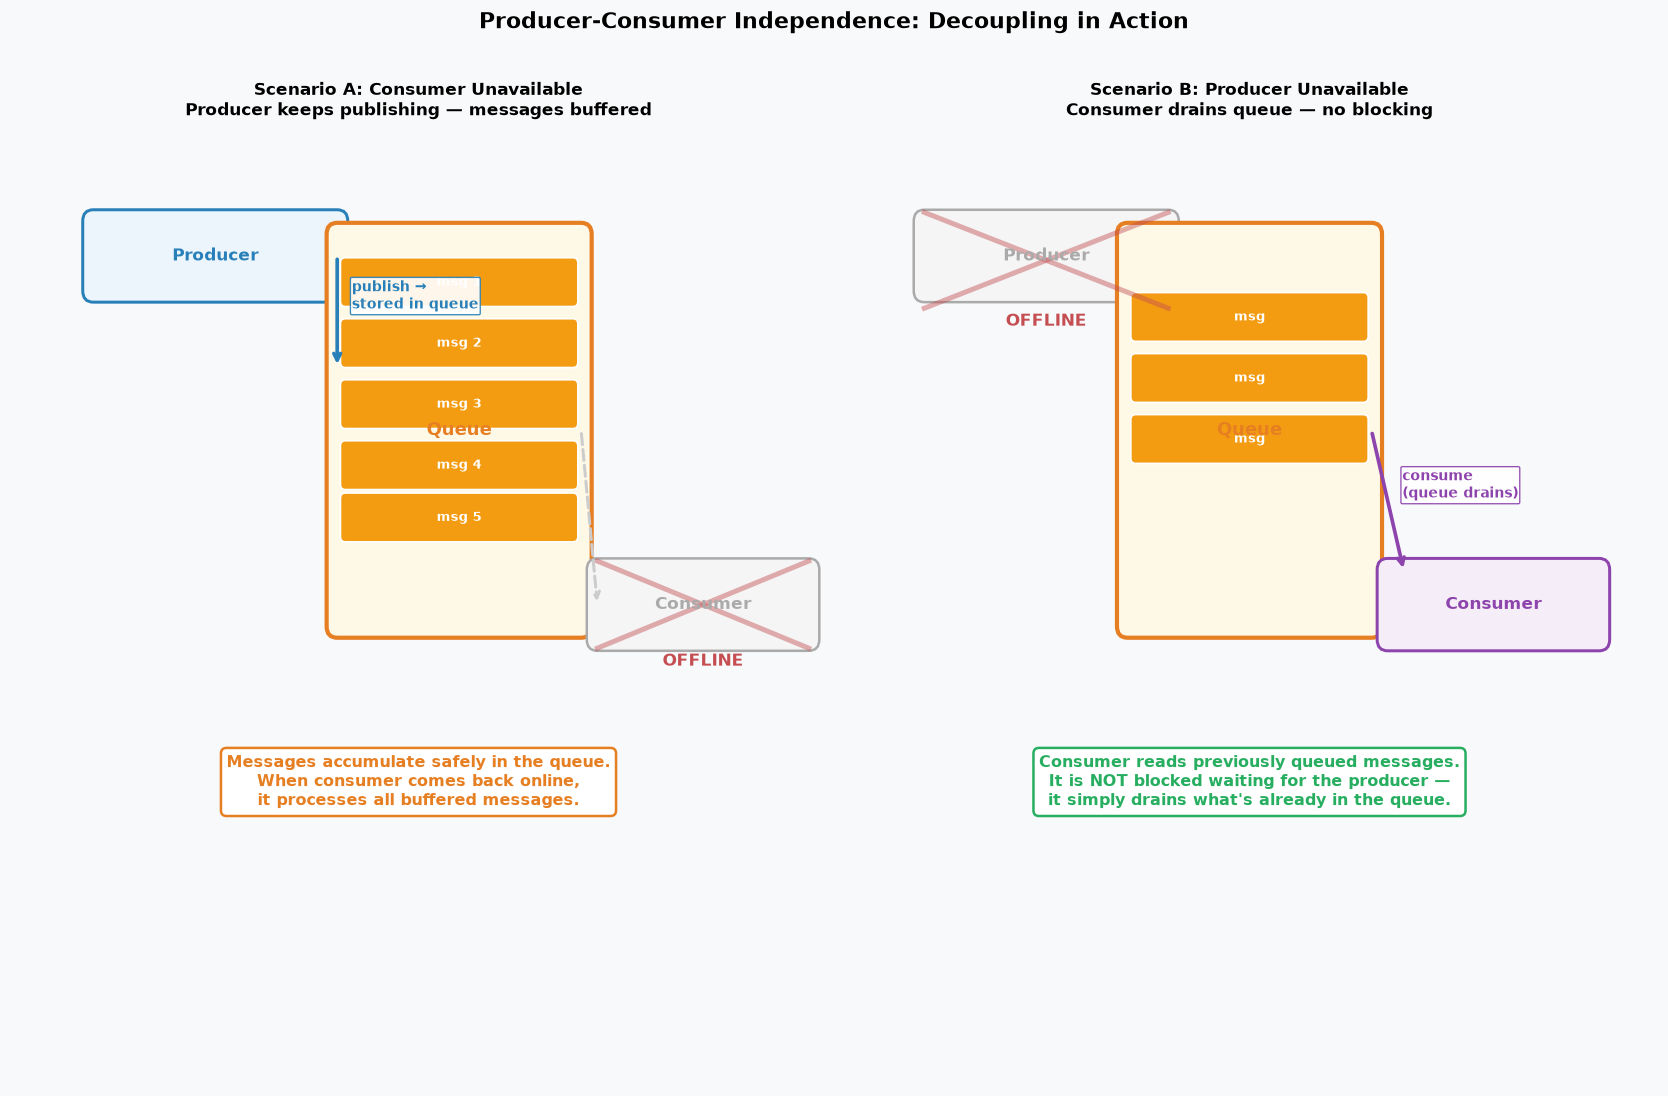

In [4]:
# Producer / Consumer independence: availability when the other is down

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
fig.patch.set_facecolor(C_GRAY)

def rbox(ax, x, y, w, h, label, color, bg='white', sub='', fs=9.5, lw=1.8):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.13',
                       facecolor=bg, edgecolor=color, lw=lw)
    ax.add_patch(r)
    ax.text(x, y + (0.16 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.26, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.85)

def arr(ax, x1, y1, x2, y2, label, color, lw=2.0, style='->'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle=style, color=color, lw=lw))
    if label:
        mx, my = (x1 + x2)/2 + 0.18, (y1 + y2)/2 + 0.18
        ax.text(mx, my, label, ha='left', va='center',
                fontsize=8.5, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                          edgecolor=color, lw=0.8, alpha=0.92))

# ── Panel A: Consumer is unavailable ─────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 11)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Scenario A: Consumer Unavailable\nProducer keeps publishing — messages buffered',
             fontsize=10, fontweight='bold')

rbox(ax, 2.5, 9.5, 3.0, 0.8, 'Producer', C_PRODUCER, bg='#EBF5FB', fs=10)
rbox(ax, 5.5, 7.5, 3.0, 4.5, 'Queue', C_QUEUE, bg='#FEF9E7', fs=11, lw=2.5)

# Messages stacking up in queue
for i, my in enumerate([9.2, 8.5, 7.8, 7.1, 6.5]):
    r = FancyBboxPatch((4.1, my - 0.22), 2.8, 0.44,
                       boxstyle='round,pad=0.06',
                       facecolor=C_MSG, edgecolor='white', lw=1.0)
    ax.add_patch(r)
    ax.text(5.5, my, f'msg {i+1}', ha='center', va='center',
            fontsize=8, fontweight='bold', color='white')

arr(ax, 4.0, 9.5, 4.0, 8.22, 'publish →\nstored in queue', C_PRODUCER, lw=2.2)

# Consumer — offline
rbox(ax, 8.5, 5.5, 2.6, 0.8, 'Consumer', '#AAA', bg='#F5F5F5', fs=10, lw=1.5)
ax.text(8.5, 4.8, 'OFFLINE', ha='center', fontsize=10,
        fontweight='bold', color=C_RED)
ax.plot([7.2, 9.8], [5.0, 6.0], color=C_RED, lw=3, alpha=0.45)
ax.plot([7.2, 9.8], [6.0, 5.0], color=C_RED, lw=3, alpha=0.45)

# Dashed arrow → offline consumer
ax.annotate('', xy=(7.2, 5.5), xytext=(7.0, 7.5),
            arrowprops=dict(arrowstyle='->', color='#CCC', lw=1.8,
                            linestyle='dashed'))

ax.text(5.0, 3.2,
        'Messages accumulate safely in the queue.\n'
        'When consumer comes back online,\nit processes all buffered messages.',
        ha='center', fontsize=9.5, color=C_QUEUE, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor=C_QUEUE, lw=1.5))

# ── Panel B: Producer is unavailable ─────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 11)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Scenario B: Producer Unavailable\nConsumer drains queue — no blocking',
             fontsize=10, fontweight='bold')

# Producer — offline
rbox(ax, 2.5, 9.5, 3.0, 0.8, 'Producer', '#AAA', bg='#F5F5F5', fs=10, lw=1.5)
ax.text(2.5, 8.7, 'OFFLINE', ha='center', fontsize=10,
        fontweight='bold', color=C_RED)
ax.plot([1.0, 4.0], [8.9, 10.0], color=C_RED, lw=3, alpha=0.45)
ax.plot([1.0, 4.0], [10.0, 8.9], color=C_RED, lw=3, alpha=0.45)

# Queue with some remaining messages
rbox(ax, 5.0, 7.5, 3.0, 4.5, 'Queue', C_QUEUE, bg='#FEF9E7', fs=11, lw=2.5)
for my in [8.8, 8.1, 7.4]:
    r = FancyBboxPatch((3.6, my - 0.22), 2.8, 0.44,
                       boxstyle='round,pad=0.06',
                       facecolor=C_MSG, edgecolor='white', lw=1.0)
    ax.add_patch(r)
    ax.text(5.0, my, 'msg', ha='center', va='center',
            fontsize=8, fontweight='bold', color='white')

# Consumer — active, draining queue
rbox(ax, 8.0, 5.5, 2.6, 0.8, 'Consumer', C_CONSUMER, bg='#F5EEF8', fs=10)
arr(ax, 6.5, 7.5, 7.0 - 0.1, 5.88, 'consume\n(queue drains)', C_CONSUMER, lw=2.2)

ax.text(5.0, 3.2,
        'Consumer reads previously queued messages.\n'
        'It is NOT blocked waiting for the producer —\n'
        'it simply drains what\'s already in the queue.',
        ha='center', fontsize=9.5, color=C_ASYNC, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor=C_ASYNC, lw=1.5))

plt.suptitle('Producer-Consumer Independence: Decoupling in Action',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day9_independence.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Consumer Unavailable:**  
The consumer (grey, OFFLINE) has an X drawn over it and a dashed arrow shows the consumer is unreachable. Messages accumulate as slots inside the queue (5 messages stacked). The producer continues publishing normally — it cannot tell or care that the consumer is down. When the consumer recovers, it will process all 5 buffered messages.

**Right — Producer Unavailable:**  
The producer (grey, OFFLINE) has an X drawn over it. Three messages are already sitting in the queue from earlier. The consumer (healthy, purple) continues pulling from the queue and processing. It is not blocked — it simply drains what exists until the queue empties.

## 5. Autoscaling Workers Based on Queue Depth

> "When the size of the queue becomes large, more workers are added to reduce the processing time. However, if the queue is empty most of the time, the number of workers can be reduced." — Day 9

This is the core scaling insight: **queue depth is the autoscaling signal**.

- Queue depth rising → add workers
- Queue depth near zero → remove workers

This is fundamentally different from scaling based on CPU or request rate. A worker that is idle (waiting for jobs) costs money but provides no value — the queue depth signal prevents this waste. AWS SQS + Auto Scaling Groups, Kubernetes KEDA, and Celery all support queue-depth scaling.

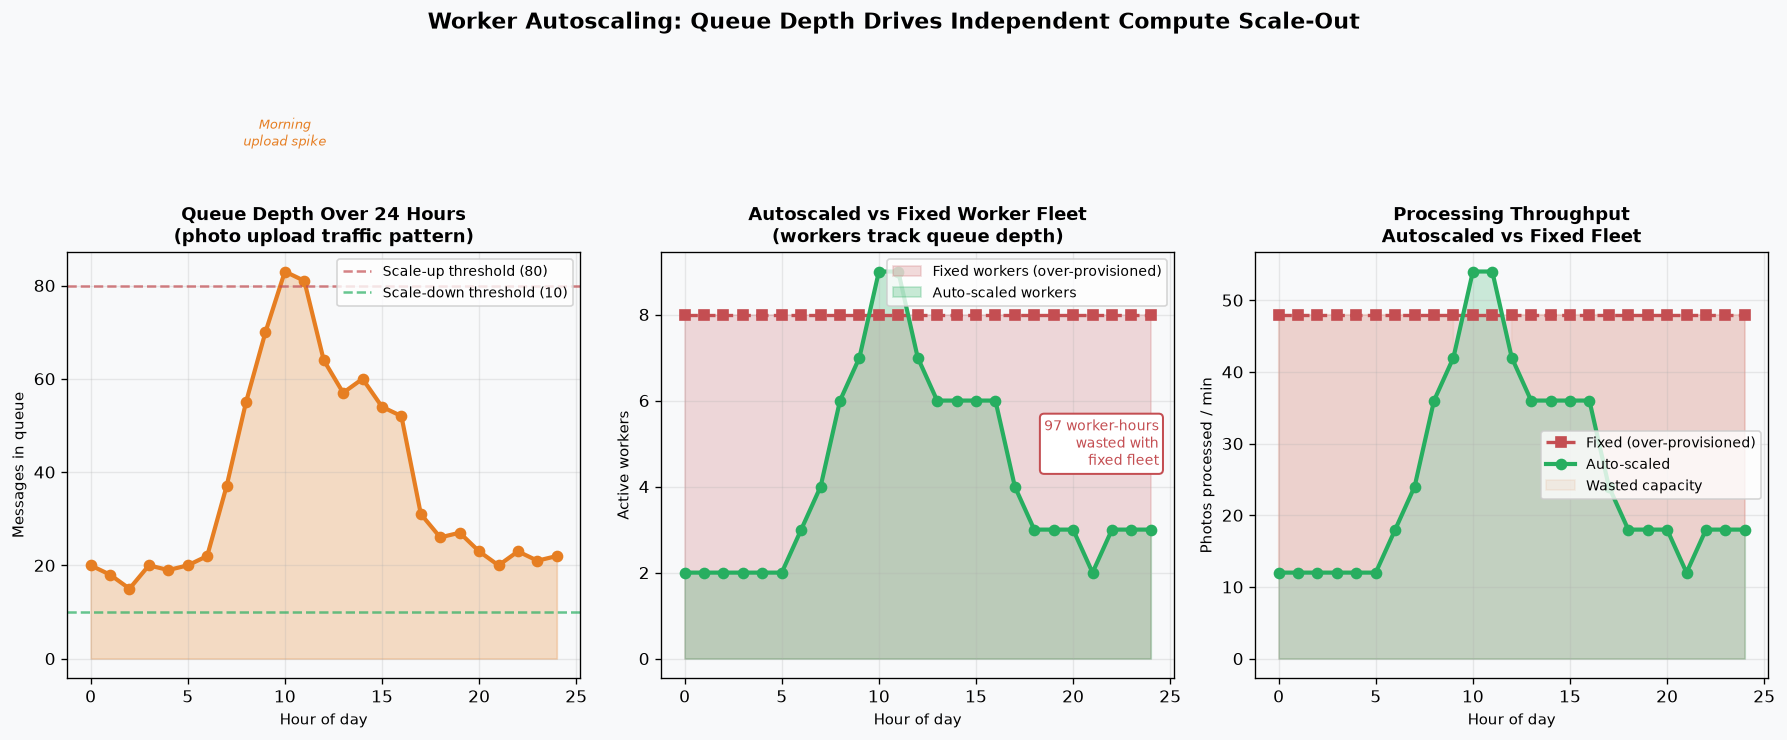

In [5]:
# Autoscaling workers based on queue depth

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.patch.set_facecolor(C_GRAY)

np.random.seed(9)
hours = np.arange(0, 25)

# Simulated queue depth over 24 hours (upload spike mid-morning, quiet overnight)
queue_depth = np.clip(
    20 + 60 * np.exp(-((hours - 10)**2) / 8) +
    30 * np.exp(-((hours - 15)**2) / 6) +
    np.random.normal(0, 4, 25), 0, 120).astype(int)

# Workers scale proportionally to queue depth (target: ~10 msgs/worker)
workers_scaled = np.ceil(queue_depth / 10).clip(1, 15).astype(int)
workers_fixed  = np.full(25, 8)   # over-provisioned fixed fleet

# ── Left: queue depth over time ───────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(C_GRAY)
ax.fill_between(hours, queue_depth, alpha=0.25, color=C_QUEUE)
ax.plot(hours, queue_depth, 'o-', color=C_QUEUE, lw=2.5, ms=6)
ax.axhline(80, color=C_RED,    lw=1.5, linestyle='--', alpha=0.7,
           label='Scale-up threshold (80)')
ax.axhline(10, color=C_GREEN,  lw=1.5, linestyle='--', alpha=0.7,
           label='Scale-down threshold (10)')
ax.set_xlabel('Hour of day', fontsize=9)
ax.set_ylabel('Messages in queue', fontsize=9)
ax.set_title('Queue Depth Over 24 Hours\n(photo upload traffic pattern)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(alpha=0.25)
ax.text(10, 110, 'Morning\nupload spike', ha='center',
        fontsize=8, color=C_QUEUE, fontstyle='italic')

# ── Middle: workers vs queue depth ───────────────────────────────────────────
ax = axes[1]
ax.set_facecolor(C_GRAY)
ax.fill_between(hours, workers_fixed, alpha=0.20, color=C_RED,
                label='Fixed workers (over-provisioned)')
ax.fill_between(hours, workers_scaled, alpha=0.25, color=C_ASYNC,
                label='Auto-scaled workers')
ax.plot(hours, workers_fixed,  's--', color=C_RED,   lw=2.0, ms=6)
ax.plot(hours, workers_scaled, 'o-',  color=C_ASYNC, lw=2.5, ms=6)

ax.set_xlabel('Hour of day', fontsize=9)
ax.set_ylabel('Active workers', fontsize=9)
ax.set_title('Autoscaled vs Fixed Worker Fleet\n(workers track queue depth)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(alpha=0.25)

waste = (workers_fixed - workers_scaled).clip(0).sum()
ax.text(0.97, 0.55,
        f'{waste} worker-hours\nwasted with\nfixed fleet',
        ha='right', va='center', transform=ax.transAxes, fontsize=8.5,
        color=C_RED,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=C_RED, lw=1.2))

# ── Right: processing throughput ─────────────────────────────────────────────
ax = axes[2]
ax.set_facecolor(C_GRAY)
# Each worker processes ~6 photos/min; throughput = workers * 6
tput_scaled = workers_scaled * 6
tput_fixed  = workers_fixed  * 6

ax.fill_between(hours, tput_fixed, alpha=0.18, color=C_RED)
ax.fill_between(hours, tput_scaled, alpha=0.22, color=C_ASYNC)
ax.plot(hours, tput_fixed,  's--', color=C_RED,   lw=2.0, ms=6,
        label='Fixed (over-provisioned)')
ax.plot(hours, tput_scaled, 'o-',  color=C_ASYNC, lw=2.5, ms=6,
        label='Auto-scaled')

# Highlight cost saving region (overnight idle fixed workers)
ax.fill_between(hours, tput_scaled, tput_fixed,
                where=(tput_fixed > tput_scaled), alpha=0.1,
                color=C_ORANGE, label='Wasted capacity')

ax.set_xlabel('Hour of day', fontsize=9)
ax.set_ylabel('Photos processed / min', fontsize=9)
ax.set_title('Processing Throughput\nAutoscaled vs Fixed Fleet',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(alpha=0.25)

plt.suptitle('Worker Autoscaling: Queue Depth Drives Independent Compute Scale-Out',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day9_autoscaling.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show

**Left — Queue Depth over 24 hours:**  
A photo-sharing app has two natural upload peaks: mid-morning (10am) and afternoon (3pm). Overnight the queue drains to near zero. The red dashed line (80 messages) triggers scale-up; the green dashed line (10 messages) triggers scale-down.

**Middle — Autoscaled vs Fixed Worker Fleet:**  
The auto-scaled fleet (green) closely tracks the queue depth. The fixed fleet (red dashed) stays at 8 workers all day — wasteful at night and potentially under-provisioned at peak. The annotation shows the total wasted worker-hours over 24 hours.

**Right — Processing Throughput:**  
Both fleets deliver similar throughput at peak. The orange shaded region (wasted capacity) shows the cost overhead of the fixed fleet during low-traffic hours — this is the direct dollar saving from autoscaling.

## 6. Message Queue Patterns

The basic single-queue pattern covers many use cases, but three additional patterns appear repeatedly in production systems:

**Fan-Out / Pub-Sub:** One message triggers multiple independent consumers. Example: a new order triggers email confirmation, inventory update, and analytics event simultaneously.

**Priority Queue:** Messages are assigned a priority level. High-priority messages are consumed before low-priority ones. Example: paid users' jobs before free-tier users' jobs.

**Dead-Letter Queue (DLQ):** Messages that fail processing after N retries are routed to a separate queue instead of blocking the main queue or being lost silently. Engineers inspect and replay DLQ messages manually.

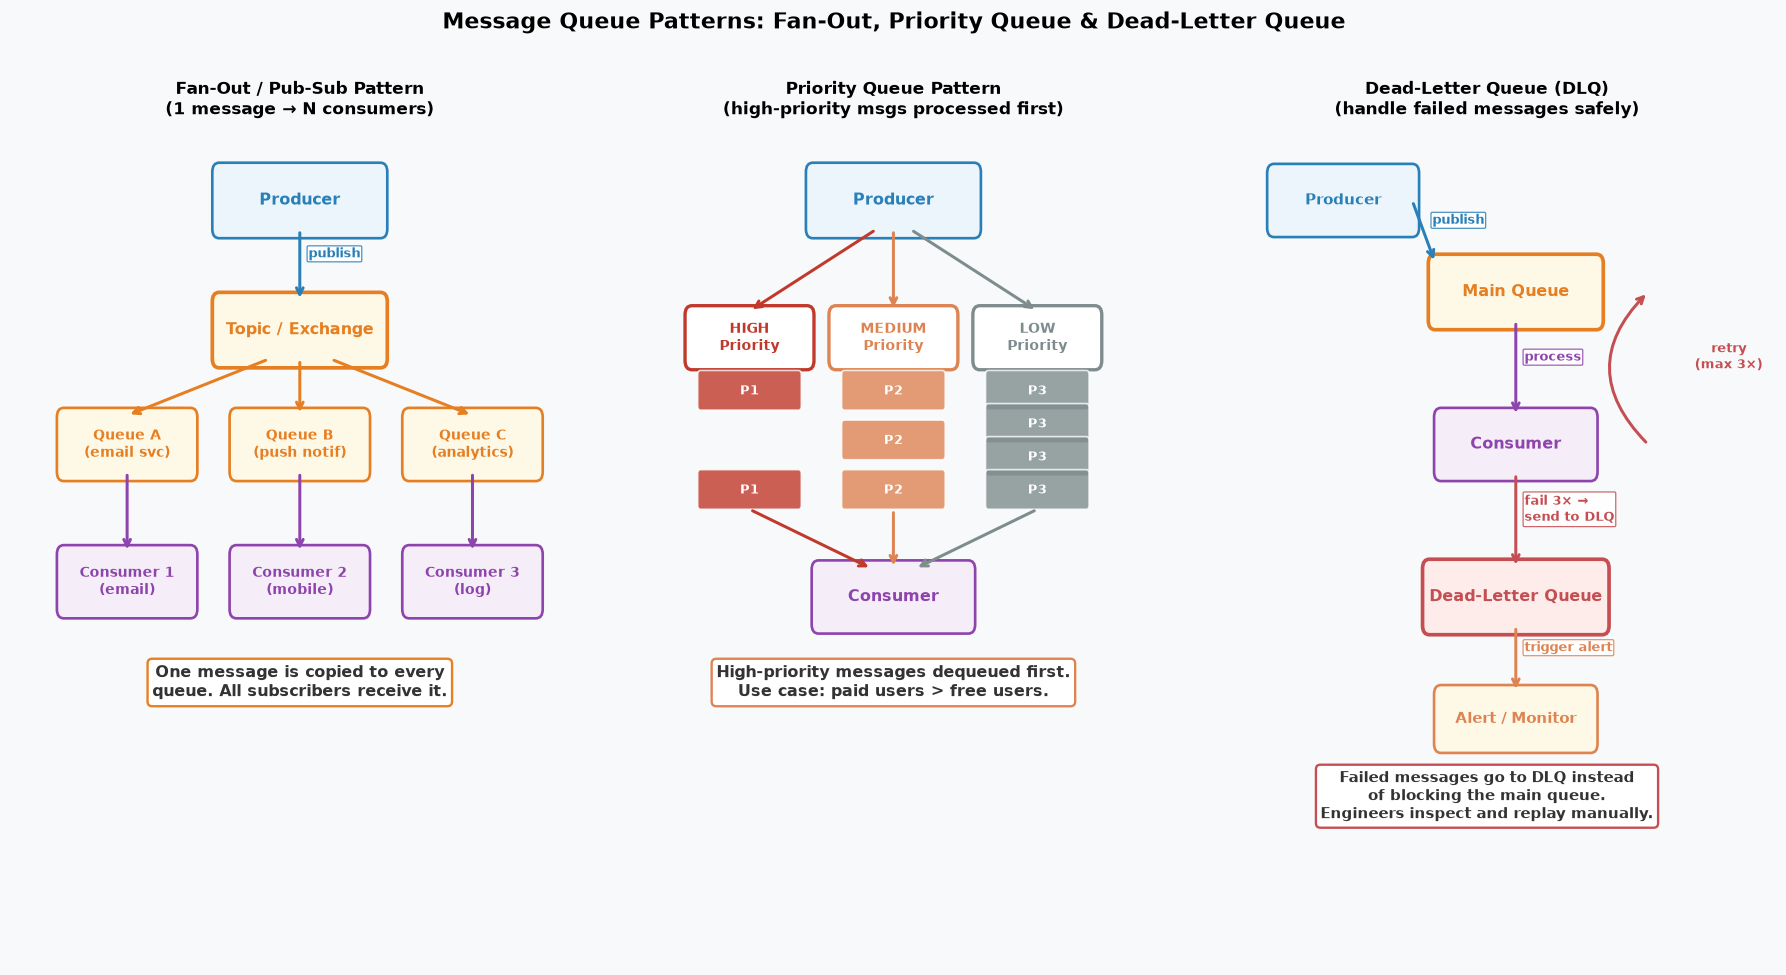

In [6]:
# Message queue patterns: fan-out, priority queue, dead-letter queue

fig, axes = plt.subplots(1, 3, figsize=(15, 8))
fig.patch.set_facecolor(C_GRAY)

def rbox(ax, x, y, w, h, label, color, bg='white', sub='', fs=9, lw=1.6):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.12',
                       facecolor=bg, edgecolor=color, lw=lw)
    ax.add_patch(r)
    ax.text(x, y + (0.15 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.24, sub, ha='center', va='center',
                fontsize=7, color=color, alpha=0.85)

def arr(ax, x1, y1, x2, y2, label, color, lw=1.8):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        mx, my = (x1 + x2)/2 + 0.15, (y1 + y2)/2 + 0.15
        ax.text(mx, my, label, ha='left', va='center',
                fontsize=8, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                          edgecolor=color, lw=0.7, alpha=0.9))

# ── Panel 1: Fan-Out (Pub/Sub) ────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 11)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Fan-Out / Pub-Sub Pattern\n(1 message → N consumers)',
             fontsize=10, fontweight='bold')

rbox(ax, 5.0, 10.0, 2.8, 0.75, 'Producer', C_PRODUCER, bg='#EBF5FB', fs=9.5)
rbox(ax, 5.0,  8.3, 2.8, 0.75, 'Topic / Exchange', C_QUEUE, bg='#FEF9E7', fs=9.5, lw=2.2)
arr(ax, 5.0, 9.62, 5.0, 8.68, 'publish', C_PRODUCER)

# Topic → 3 queues → 3 consumers
fan_data = [
    (2.0, 'Queue A\n(email svc)',    'Consumer 1\n(email)'),
    (5.0, 'Queue B\n(push notif)',   'Consumer 2\n(mobile)'),
    (8.0, 'Queue C\n(analytics)',    'Consumer 3\n(log)'),
]
for qx, qlbl, clbl in fan_data:
    arr(ax, 5.0 + (qx-5.0)*0.18, 7.92, qx, 7.18, '', C_QUEUE)
    rbox(ax, qx, 6.8, 2.2, 0.72, qlbl, C_QUEUE, bg='#FEF9E7', fs=8.5)
    arr(ax, qx, 6.44, qx, 5.38, '', C_CONSUMER)
    rbox(ax, qx, 5.0, 2.2, 0.72, clbl, C_CONSUMER, bg='#F5EEF8', fs=8.5)

ax.text(5.0, 3.5,
        'One message is copied to every\nqueue. All subscribers receive it.',
        ha='center', fontsize=9.5, color='#333', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=C_QUEUE, lw=1.4))

# ── Panel 2: Priority Queue ───────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 11)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Priority Queue Pattern\n(high-priority msgs processed first)',
             fontsize=10, fontweight='bold')

rbox(ax, 5.0, 10.0, 2.8, 0.75, 'Producer', C_PRODUCER, bg='#EBF5FB', fs=9.5)

# 3 priority lanes
pri_data = [
    (2.5, 'HIGH\nPriority', '#C0392B', ['P1', 'P1']),
    (5.0, 'MEDIUM\nPriority', C_ORANGE, ['P2', 'P2', 'P2']),
    (7.5, 'LOW\nPriority', '#7F8C8D', ['P3', 'P3', 'P3', 'P3']),
]
for qx, qlbl, qc, msgs in pri_data:
    arr(ax, 5.0 + (qx-5.0)*0.12, 9.62, qx, 8.55, '', qc)
    rbox(ax, qx, 8.2, 2.0, 0.6, qlbl, qc, bg='white', fs=8.5, lw=2.0)
    for i, (my, mlbl) in enumerate(zip(np.linspace(7.5, 6.2, len(msgs)), msgs)):
        r = FancyBboxPatch((qx - 0.85, my - 0.2), 1.7, 0.42,
                           boxstyle='round,pad=0.05',
                           facecolor=qc, edgecolor='white', lw=1.0, alpha=0.8)
        ax.add_patch(r)
        ax.text(qx, my, mlbl, ha='center', va='center',
                fontsize=7.5, fontweight='bold', color='white')

# Single consumer, processes high-priority first
rbox(ax, 5.0, 4.8, 2.6, 0.72, 'Consumer', C_CONSUMER, bg='#F5EEF8', fs=9.5)
for qx, _, qc, _ in pri_data:
    arr(ax, qx, 5.95, 5.0 + (qx-5.0)*0.15, 5.17, '', qc)

ax.text(5.0, 3.5,
        'High-priority messages dequeued first.\n'
        'Use case: paid users > free users.',
        ha='center', fontsize=9.5, color='#333', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=C_ORANGE, lw=1.4))

# ── Panel 3: Dead-Letter Queue ────────────────────────────────────────────────
ax = axes[2]
ax.set_xlim(0, 10); ax.set_ylim(0, 11)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Dead-Letter Queue (DLQ)\n(handle failed messages safely)',
             fontsize=10, fontweight='bold')

rbox(ax, 2.5, 10.0, 2.4, 0.72, 'Producer', C_PRODUCER, bg='#EBF5FB', fs=9)
rbox(ax, 5.5,  8.8, 2.8, 0.75, 'Main Queue', C_QUEUE, bg='#FEF9E7', fs=9.5, lw=2.2)
rbox(ax, 5.5,  6.8, 2.6, 0.72, 'Consumer', C_CONSUMER, bg='#F5EEF8', fs=9.5)

arr(ax, 3.7,  10.0, 4.1, 9.18, 'publish', C_PRODUCER)
arr(ax,  5.5,  8.42,  5.5, 7.17, 'process', C_CONSUMER)

# Retry loop
ax.annotate('', xy=(7.8, 8.8), xytext=(7.8, 6.8),
            arrowprops=dict(arrowstyle='->', color=C_RED, lw=1.8,
                            connectionstyle='arc3,rad=-0.5'))
ax.text(9.2, 7.8, 'retry\n(max 3×)', ha='center', fontsize=8,
        color=C_RED, fontweight='bold')

# DLQ after retries exhausted
rbox(ax, 5.5, 4.8, 3.0, 0.75, 'Dead-Letter Queue', C_RED, bg='#FDECEA',
     fs=9.5, lw=2.2)
arr(ax, 5.5, 6.42, 5.5, 5.18, 'fail 3× →\nsend to DLQ', C_RED)

# Alert
rbox(ax, 5.5, 3.2, 2.6, 0.65, 'Alert / Monitor', C_ORANGE, bg='#FEF9E7', fs=9)
arr(ax, 5.5, 4.42, 5.5, 3.55, 'trigger alert', C_ORANGE)

ax.text(5.0, 1.9,
        'Failed messages go to DLQ instead\n'
        'of blocking the main queue.\n'
        'Engineers inspect and replay manually.',
        ha='center', fontsize=9, color='#333', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=C_RED, lw=1.4))

plt.suptitle('Message Queue Patterns: Fan-Out, Priority Queue & Dead-Letter Queue',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day9_patterns.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Fan-Out:**  
One producer publishes to a topic/exchange. The topic copies the message to three separate queues (email service, push notification, analytics). Each consumer receives the same message independently. This is the foundation of event-driven microservice architectures.

**Middle — Priority Queue:**  
Three priority lanes (HIGH red, MEDIUM orange, LOW grey) with different queue depths. A single consumer always picks from the HIGH lane first, then MEDIUM, then LOW. The producer assigns priority at publish time.

**Right — Dead-Letter Queue:**  
Normal flow: producer → queue → consumer. On failure, the message is retried up to 3 times (retry loop arrow). After 3 failures, the message is moved to the DLQ (red) instead of being lost or blocking the main queue. An alert is triggered so engineers can investigate and replay.

## 7. Technology Comparison & Decision Matrix

The right MQ technology depends on throughput, ordering requirements, and whether replay is needed:

- **RabbitMQ:** Push-based, great for task queues, supports complex routing rules
- **Apache Kafka:** Pull-based log, extremely high throughput, supports message replay — ideal for event streaming and audit trails
- **AWS SQS:** Managed, simple, no ops overhead — good default for AWS-native apps
- **Redis Streams:** Low latency, in-memory, consumer groups with cursor-based replay

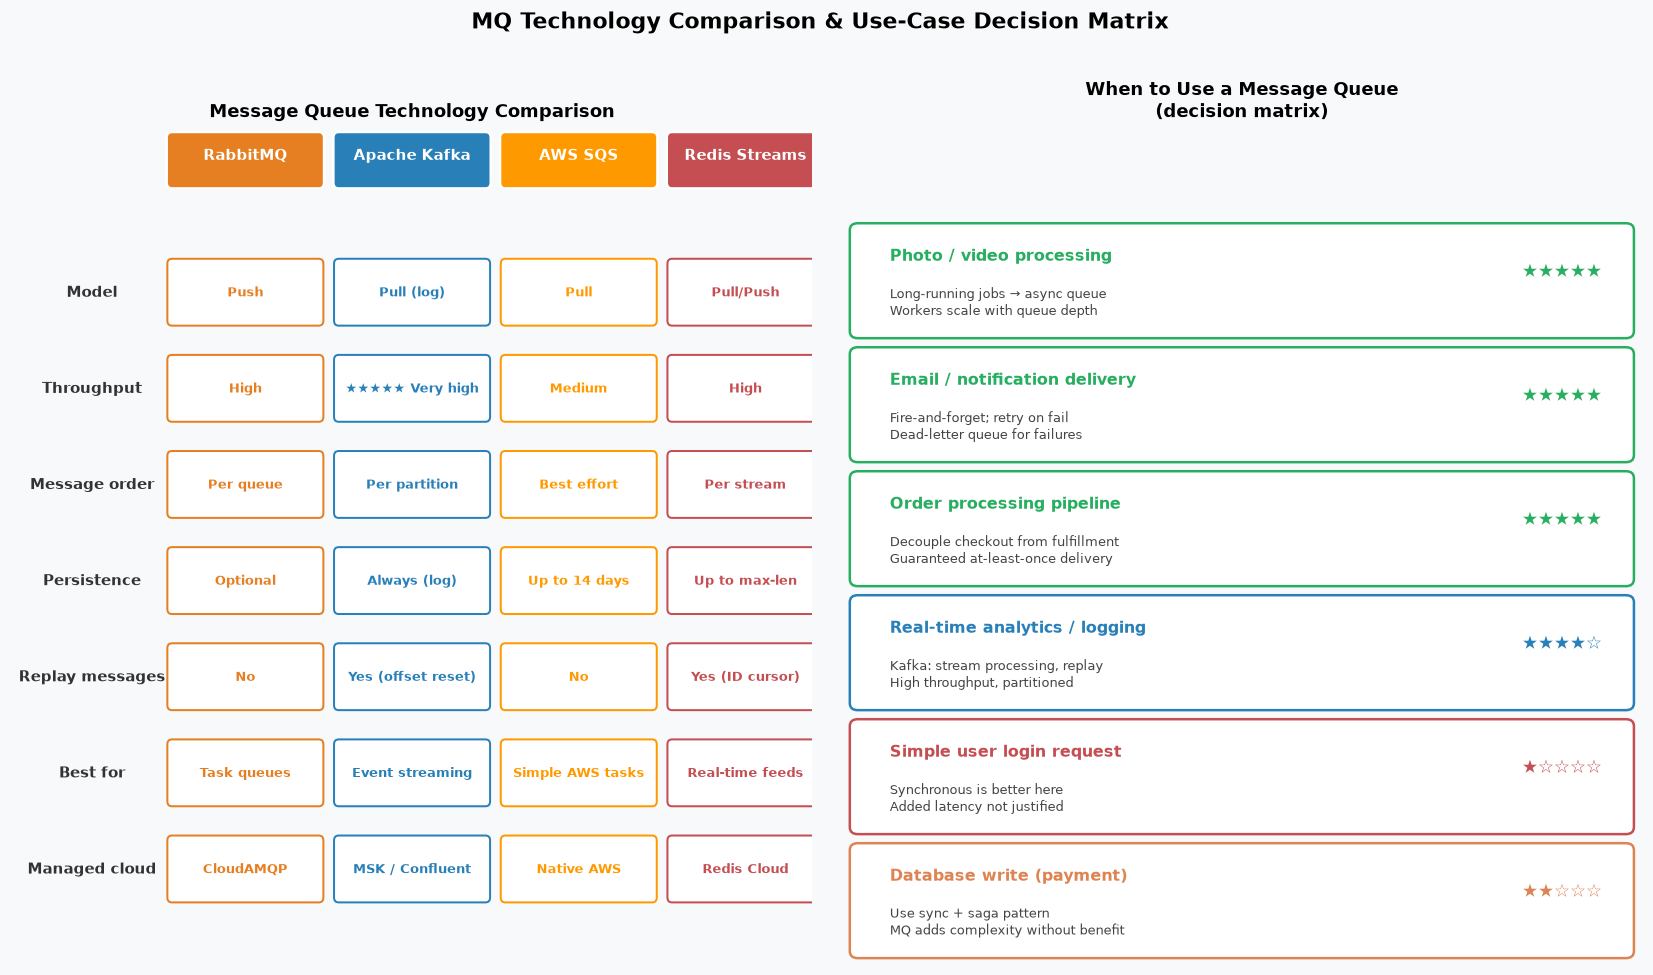

In [7]:
# MQ technology comparison + when to use which

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.patch.set_facecolor(C_GRAY)

# ── Left: technology comparison table ────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 12); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Message Queue Technology Comparison', fontsize=11, fontweight='bold')

headers = ['', 'RabbitMQ', 'Apache Kafka', 'AWS SQS', 'Redis Streams']
col_x   = [1.2, 3.5, 6.0, 8.5, 11.0]
colors  = ['#FFF', '#E67E22', '#2980B9', '#FF9900', C_RED]

# Header row
for cx, hdr, col in zip(col_x[1:], headers[1:], colors[1:]):
    r = FancyBboxPatch((cx - 1.1, 11.2), 2.2, 0.65,
                       boxstyle='round,pad=0.08',
                       facecolor=col, edgecolor='white', lw=1.5)
    ax.add_patch(r)
    ax.text(cx, 11.53, hdr, ha='center', fontsize=9,
            fontweight='bold', color='white')

rows = [
    ('Model',           'Push', 'Pull (log)', 'Pull', 'Pull/Push'),
    ('Throughput',      'High', '★★★★★ Very high', 'Medium', 'High'),
    ('Message order',   'Per queue', 'Per partition', 'Best effort', 'Per stream'),
    ('Persistence',     'Optional', 'Always (log)', 'Up to 14 days', 'Up to max-len'),
    ('Replay messages', 'No', 'Yes (offset reset)', 'No', 'Yes (ID cursor)'),
    ('Best for',        'Task queues', 'Event streaming', 'Simple AWS tasks', 'Real-time feeds'),
    ('Managed cloud',   'CloudAMQP', 'MSK / Confluent', 'Native AWS', 'Redis Cloud'),
]

y0 = 11.0
for attr, *vals in rows:
    y0 -= 1.38
    ax.text(col_x[0], y0, attr, ha='center', va='center',
            fontsize=9, fontweight='bold', color='#333')
    for cx, val, col in zip(col_x[1:], vals, colors[1:]):
        r = FancyBboxPatch((cx - 1.1, y0 - 0.4), 2.2, 0.82,
                           boxstyle='round,pad=0.07',
                           facecolor='white', edgecolor=col, lw=1.2)
        ax.add_patch(r)
        ax.text(cx, y0, val, ha='center', va='center',
                fontsize=8, color=col, fontweight='bold')

# ── Right: use-case decision matrix ──────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('When to Use a Message Queue\n(decision matrix)', fontsize=11, fontweight='bold')

use_cases = [
    ('Photo / video processing',
     'Long-running jobs → async queue\nWorkers scale with queue depth',
     C_ASYNC, '★★★★★'),
    ('Email / notification delivery',
     'Fire-and-forget; retry on fail\nDead-letter queue for failures',
     C_ASYNC, '★★★★★'),
    ('Order processing pipeline',
     'Decouple checkout from fulfillment\nGuaranteed at-least-once delivery',
     C_ASYNC, '★★★★★'),
    ('Real-time analytics / logging',
     'Kafka: stream processing, replay\nHigh throughput, partitioned',
     C_PRODUCER, '★★★★☆'),
    ('Simple user login request',
     'Synchronous is better here\nAdded latency not justified',
     C_RED, '★☆☆☆☆'),
    ('Database write (payment)',
     'Use sync + saga pattern\nMQ adds complexity without benefit',
     C_ORANGE, '★★☆☆☆'),
]

y0 = 11.5
for (uc, detail, color, stars) in use_cases:
    y0 -= 1.78
    r = FancyBboxPatch((0.2, y0 - 0.65), 9.6, 1.45,
                       boxstyle='round,pad=0.1',
                       facecolor='white', edgecolor=color, lw=1.5)
    ax.add_patch(r)
    ax.text(0.6, y0 + 0.42, uc, ha='left', va='center',
            fontsize=9.5, fontweight='bold', color=color)
    ax.text(0.6, y0 - 0.24, detail, ha='left', va='center',
            fontsize=8, color='#444')
    ax.text(9.5, y0 + 0.2, stars, ha='right', va='center',
            fontsize=11, color=color)

plt.suptitle('MQ Technology Comparison & Use-Case Decision Matrix',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day9_technologies.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Technology comparison table:**  
Seven attributes (model, throughput, ordering, persistence, replay, best-for, managed cloud) compared across four technologies. Kafka stands out on throughput and replay; SQS on simplicity; RabbitMQ on routing flexibility; Redis Streams on latency.

**Right — Use-case decision matrix:**  
Six scenarios with star ratings. Green 5-star cases (photo processing, notifications, order pipeline) are classic MQ sweet spots: long-running, fire-and-forget, retriable. Red/orange cases (user login, payment write) are where synchronous is actually better — adding a queue introduces unnecessary complexity and latency for operations that need an immediate response.

## 8. Architecture Evolution & Scorecard

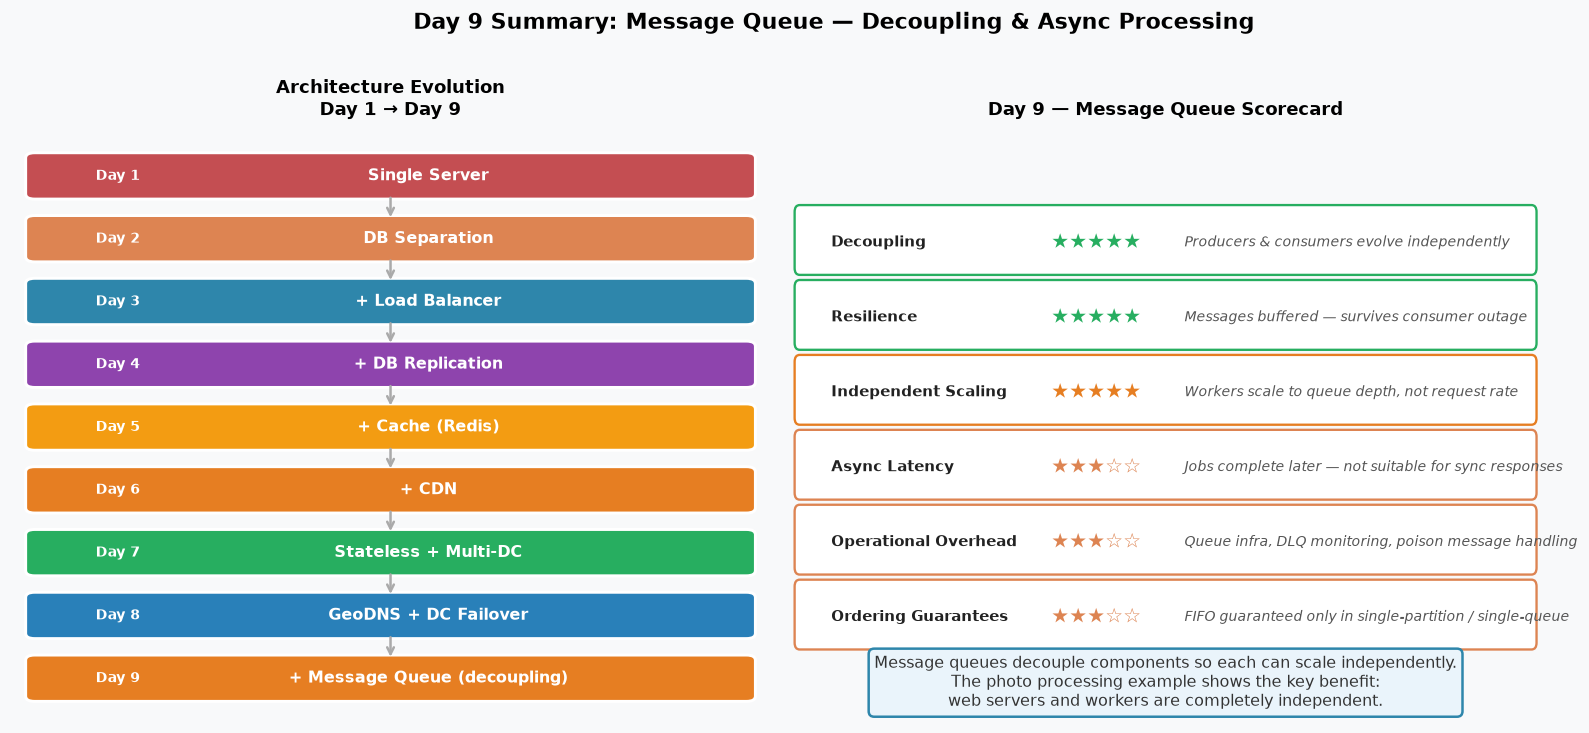

Day 9 complete.


In [8]:
# Day 9 Scorecard + Evolution Day 1 -> 9

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(C_GRAY)

# ── Left: evolution ────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 14)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Architecture Evolution\nDay 1 → Day 9', fontsize=11, fontweight='bold')

days = [
    ('Day 1', 'Single Server',                    '#C44E52'),
    ('Day 2', 'DB Separation',                    '#DD8452'),
    ('Day 3', '+ Load Balancer',                  '#2E86AB'),
    ('Day 4', '+ DB Replication',                 '#8E44AD'),
    ('Day 5', '+ Cache (Redis)',                  '#F39C12'),
    ('Day 6', '+ CDN',                            '#E67E22'),
    ('Day 7', 'Stateless + Multi-DC',             '#27AE60'),
    ('Day 8', 'GeoDNS + DC Failover',             '#2980B9'),
    ('Day 9', '+ Message Queue (decoupling)',      C_QUEUE),
]
ys = np.linspace(12.8, 1.0, len(days))
for i, ((day, label, color), y) in enumerate(zip(days, ys)):
    r = FancyBboxPatch((0.3, y - 0.42), 9.4, 0.85,
                       boxstyle='round,pad=0.12',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(1.4, y, day, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')
    ax.text(5.5, y, label, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='white')
    if i < len(days) - 1:
        ax.annotate('', xy=(5, ys[i+1] + 0.43), xytext=(5, y - 0.43),
                    arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.5))

# ── Right: scorecard ──────────────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 12); ax.set_ylim(0, 7)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Day 9 — Message Queue Scorecard', fontsize=11, fontweight='bold')

metrics = [
    ('Decoupling',           '★★★★★', C_ASYNC,
     'Producers & consumers evolve independently'),
    ('Resilience',           '★★★★★', C_ASYNC,
     'Messages buffered — survives consumer outage'),
    ('Independent Scaling',  '★★★★★', C_QUEUE,
     'Workers scale to queue depth, not request rate'),
    ('Async Latency',        '★★★☆☆', C_ORANGE,
     'Jobs complete later — not suitable for sync responses'),
    ('Operational Overhead', '★★★☆☆', C_ORANGE,
     'Queue infra, DLQ monitoring, poison message handling'),
    ('Ordering Guarantees',  '★★★☆☆', C_ORANGE,
     'FIFO guaranteed only in single-partition / single-queue'),
]

y0 = 6.5
for (metric, stars, color, detail) in metrics:
    y0 -= 0.88
    r = FancyBboxPatch((0.2, y0 - 0.3), 11.6, 0.66,
                       boxstyle='round,pad=0.08',
                       facecolor='white', edgecolor=color, lw=1.4)
    ax.add_patch(r)
    ax.text(0.7,  y0, metric, ha='left',   va='center',
            fontsize=9,  fontweight='bold', color='#222')
    ax.text(4.9,  y0, stars,  ha='center', va='center',
            fontsize=12, color=color)
    ax.text(6.3,  y0, detail, ha='left',   va='center',
            fontsize=8.5, color='#555', fontstyle='italic')

ax.text(6, 0.45,
        'Message queues decouple components so each can scale independently.\n'
        'The photo processing example shows the key benefit:\n'
        'web servers and workers are completely independent.',
        ha='center', va='center', fontsize=9.5, color='#333',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#EAF4FB',
                  edgecolor=C_TEAL, lw=1.5))

plt.suptitle('Day 9 Summary: Message Queue — Decoupling & Async Processing',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day9_scorecard.png', dpi=130, bbox_inches='tight')
plt.show()
print("Day 9 complete.")


### What this shows

**Left — Evolution Day 1 → Day 9:**  
Day 9 adds the message queue as a horizontal decoupling layer between the web tier and the processing/worker tier. The web servers (from Days 3-7) continue to handle synchronous HTTP requests; the message queue offloads all long-running async work to an independently scalable worker fleet.

**Right — Day 9 Scorecard:**
- **Decoupling (5/5):** Producers and consumers evolve, deploy, and fail independently.
- **Resilience (5/5):** Messages buffered in queue survive consumer crashes; no data loss on outage.
- **Independent Scaling (5/5):** Workers scale to queue depth — not to request rate or web server count.
- **Async Latency (3/5):** Jobs complete later, not immediately — unsuitable for operations that need a synchronous response.
- **Operational Overhead (3/5):** Queue infra, DLQ monitoring, and poison message handling add operational complexity.
- **Ordering Guarantees (3/5):** Strict FIFO only within a single partition/queue; cross-consumer ordering is not guaranteed by default.

**Key insight:** Message queues solve the coupling problem that emerges at scale. When two components must communicate but should not depend on each other's availability, a queue is the right answer.